# Compare spins

In [9]:
import requests
import time
import io
import os

import numpy as np
import pandas as pd

import rocks

from figure_mask import compute_mask, print_statistics

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")

### SSOFT

In [10]:
# You need SSOFT version 2024.09
# see fink_spins/generate_data.py
data_fink = "../../"
ssoft = pd.read_parquet(os.path.join(data_fink, "data", "ztf", "sso_ZTF.parquet"))

In [11]:
flavors = ["SSHG1G2", "SHG1G2"]

In [12]:
maskFINK_inter = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model='FINK', kind='inter')
maskFINK_union = compute_mask(ssoft, thres_spin=1e-3, thres_phase=1e-3, R_min=0.30, model='FINK', kind='union')

for model in ['HG', 'HG1G2', 'SHG1G2', 'SSHG1G2', 'FINK']:
    print_statistics(ssoft, model)
    print()

mask = maskFINK_union
print(sum(mask))

  All data       : 148507  (100.00%)
  Mask HG (g∩r) : 145706  ( 98.11%)
  Mask HG (gUr) : 145715  ( 98.12%)

  All data       : 148507  (100.00%)
  Mask HG1G2 (g∩r) :  62156  ( 41.85%)
  Mask HG1G2 (gUr) : 107999  ( 72.72%)

  All data       : 148507  (100.00%)
  Mask SHG1G2 (g∩r) :  81827  ( 55.10%)
  Mask SHG1G2 (gUr) : 121580  ( 81.87%)

  All data       : 148507  (100.00%)
  Mask SSHG1G2 (g∩r) :  75915  ( 51.12%)
  Mask SSHG1G2 (gUr) : 112173  ( 75.53%)

  All data       : 148507  (100.00%)
  Mask FINK (g∩r) :  56442  ( 38.01%)
  Mask FINK (gUr) :  95584  ( 64.36%)

95584


## Comparison

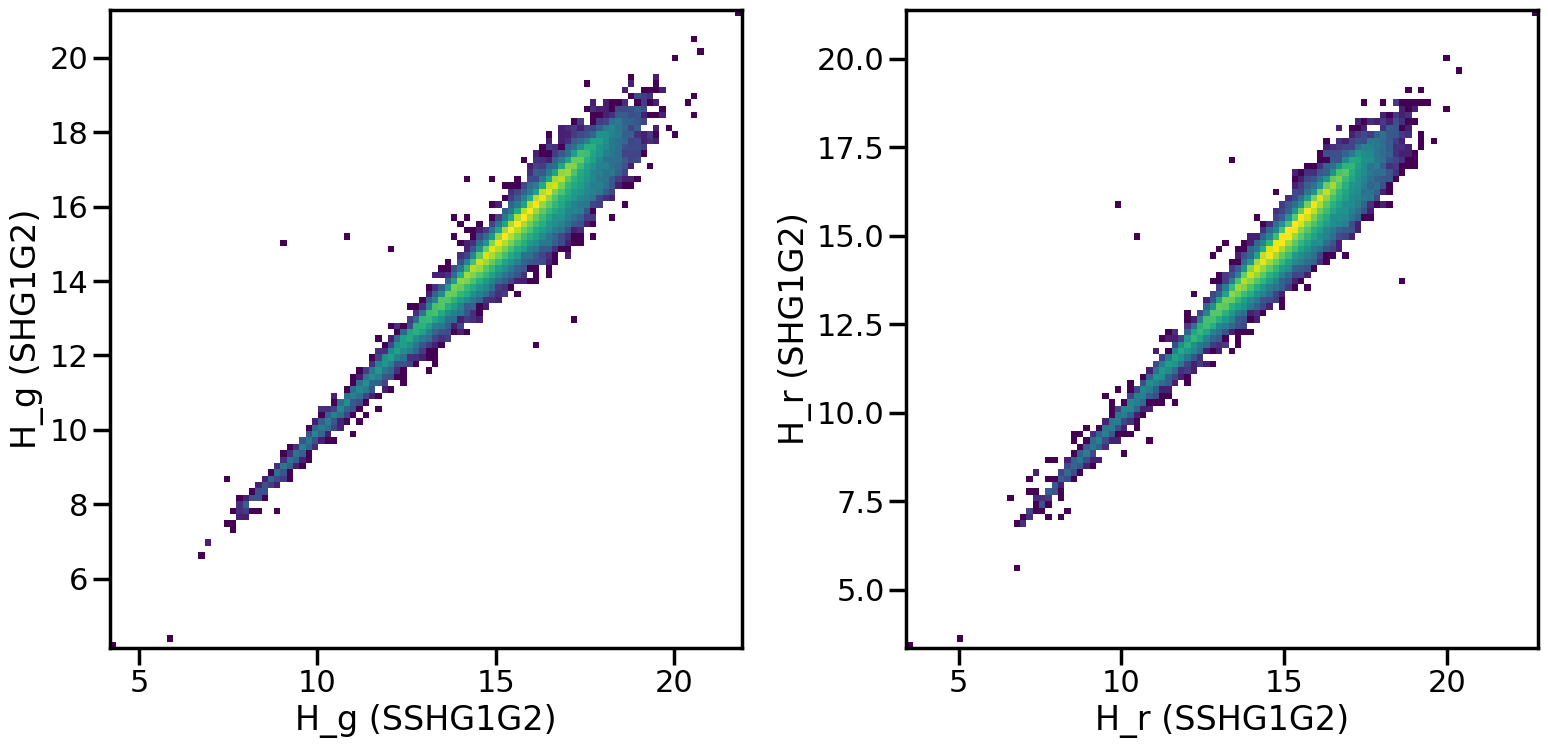

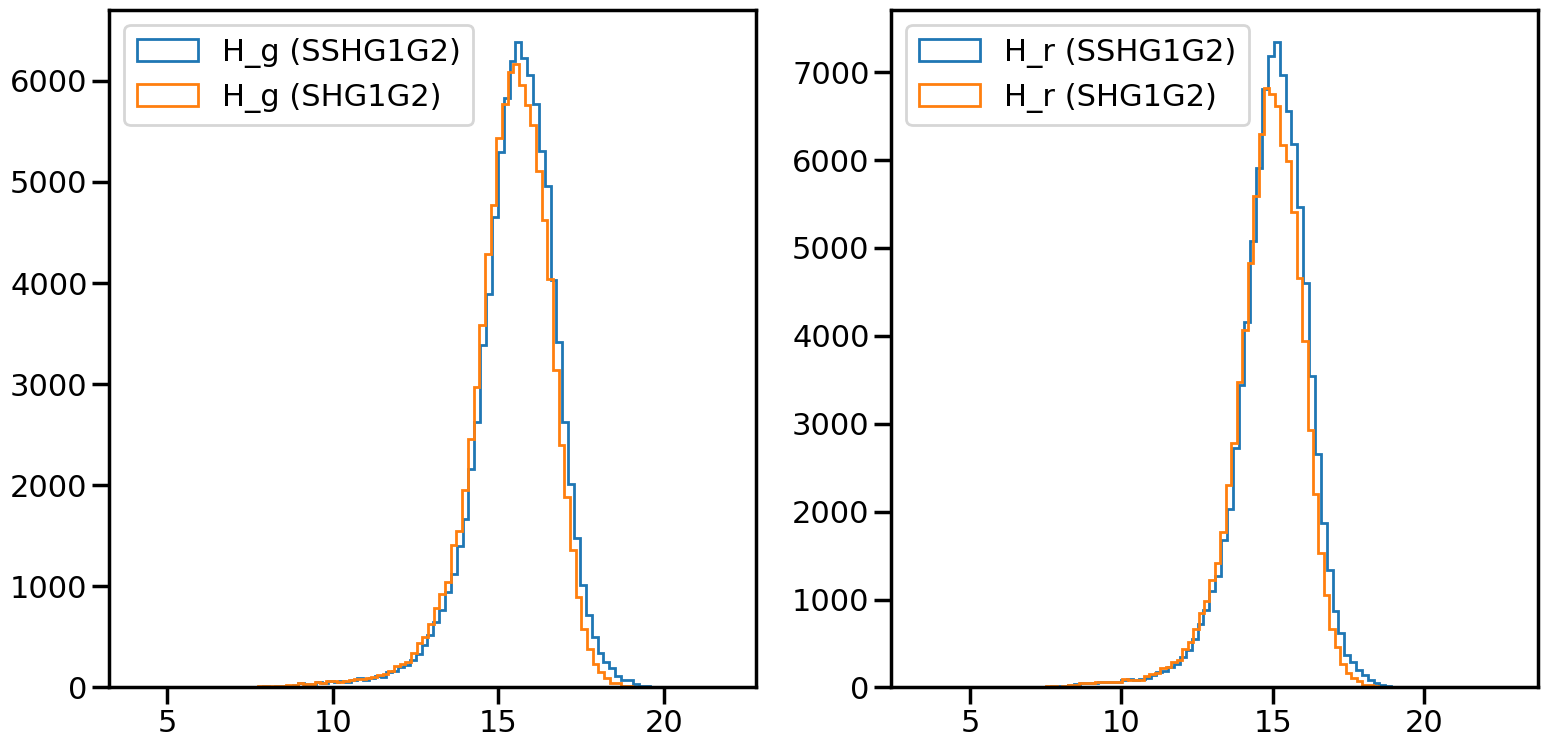

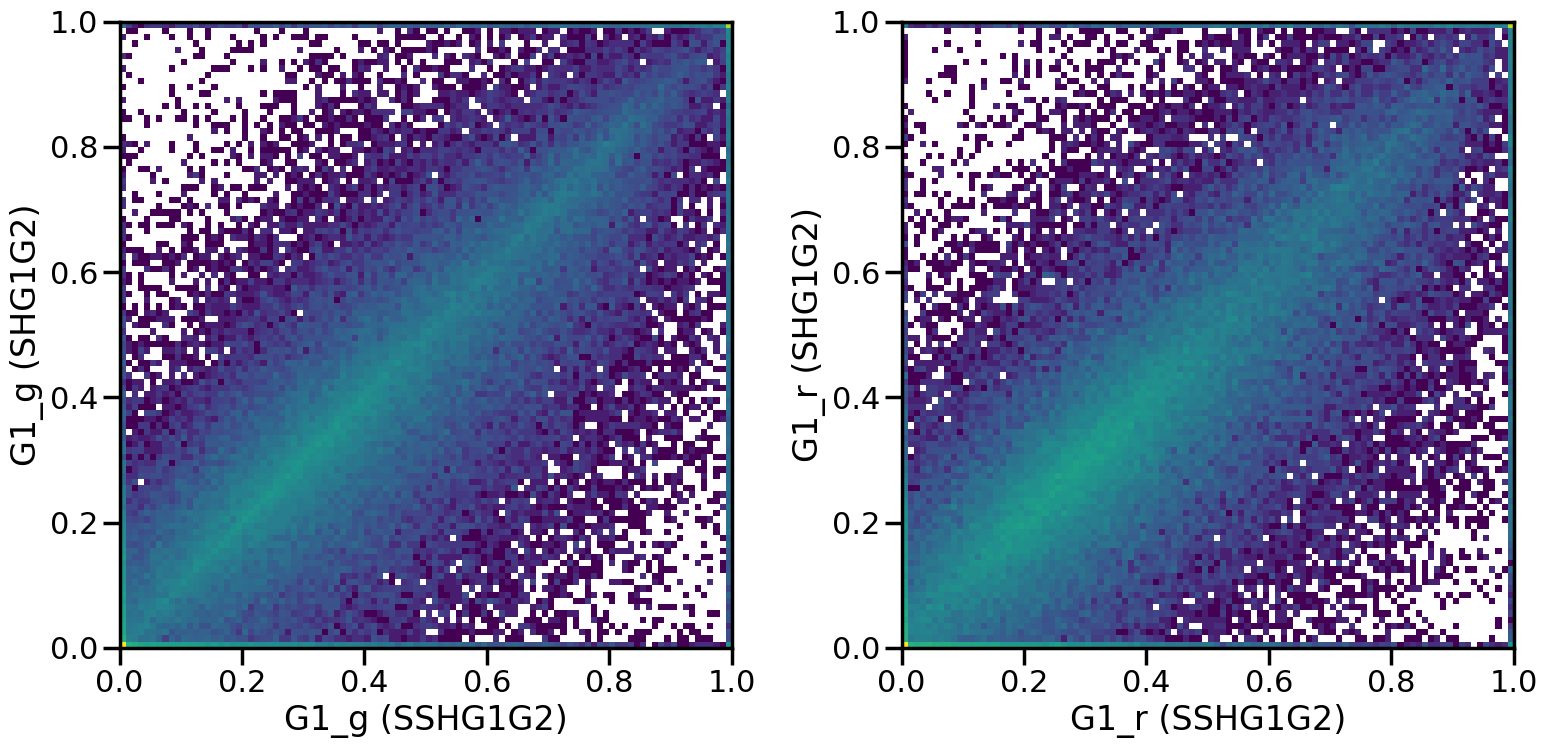

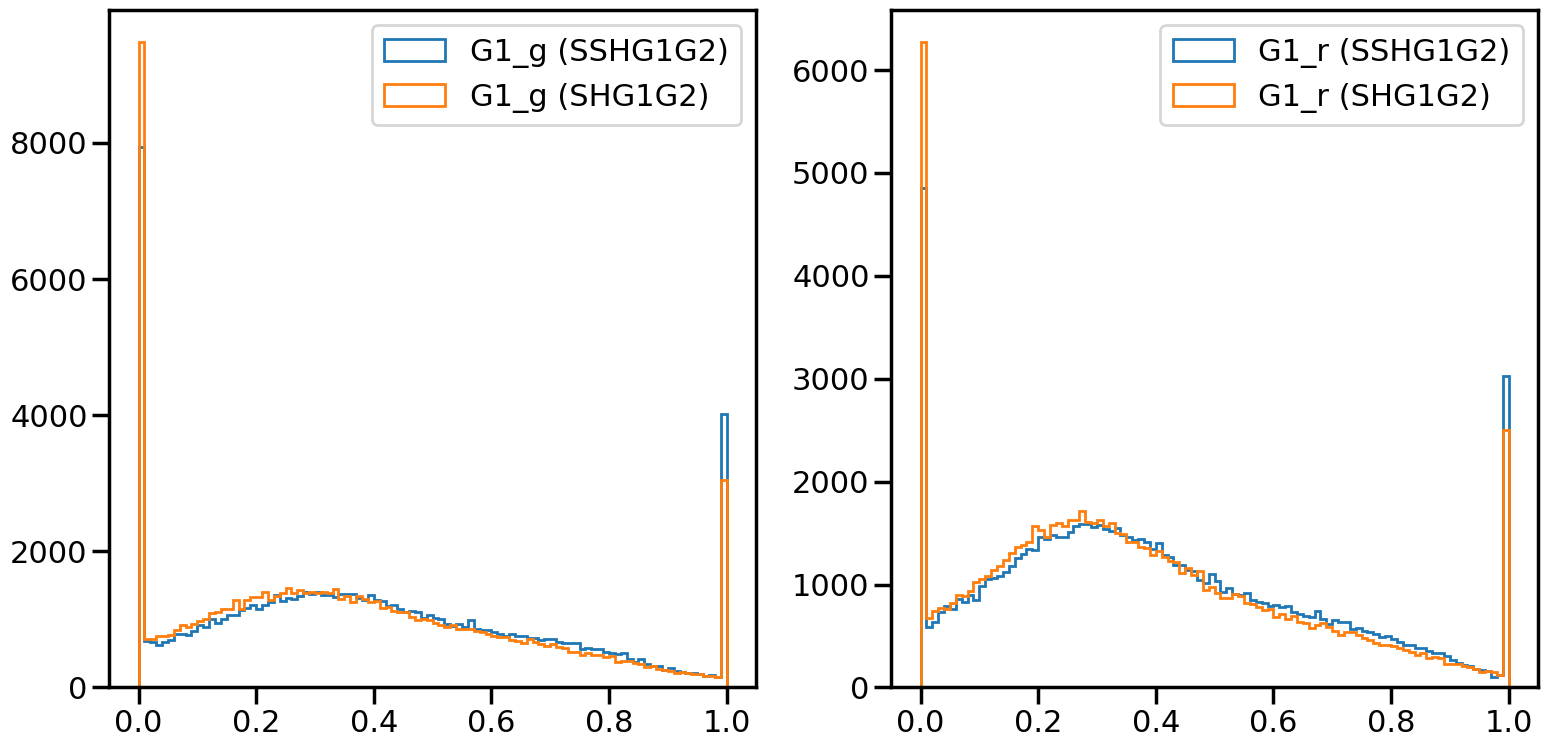

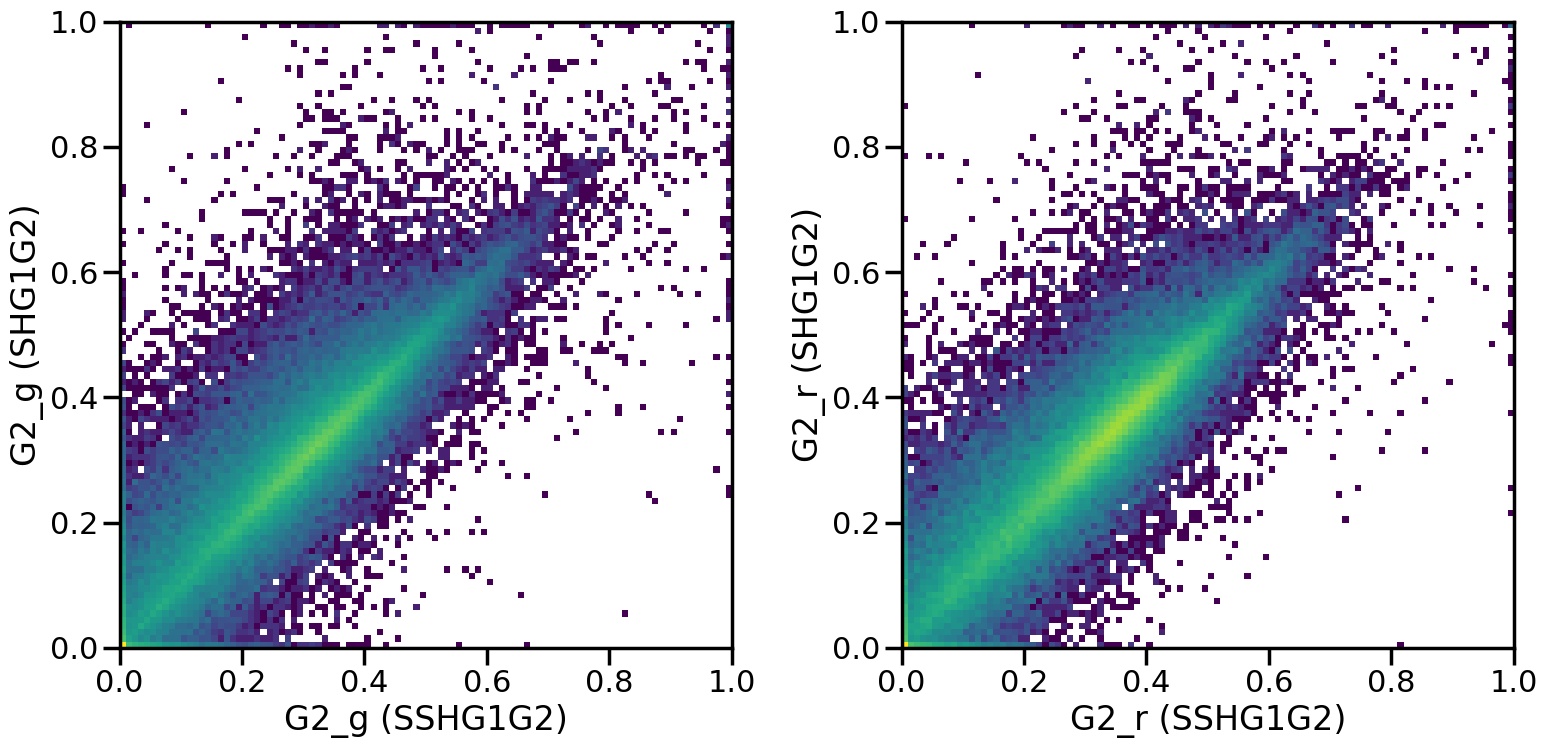

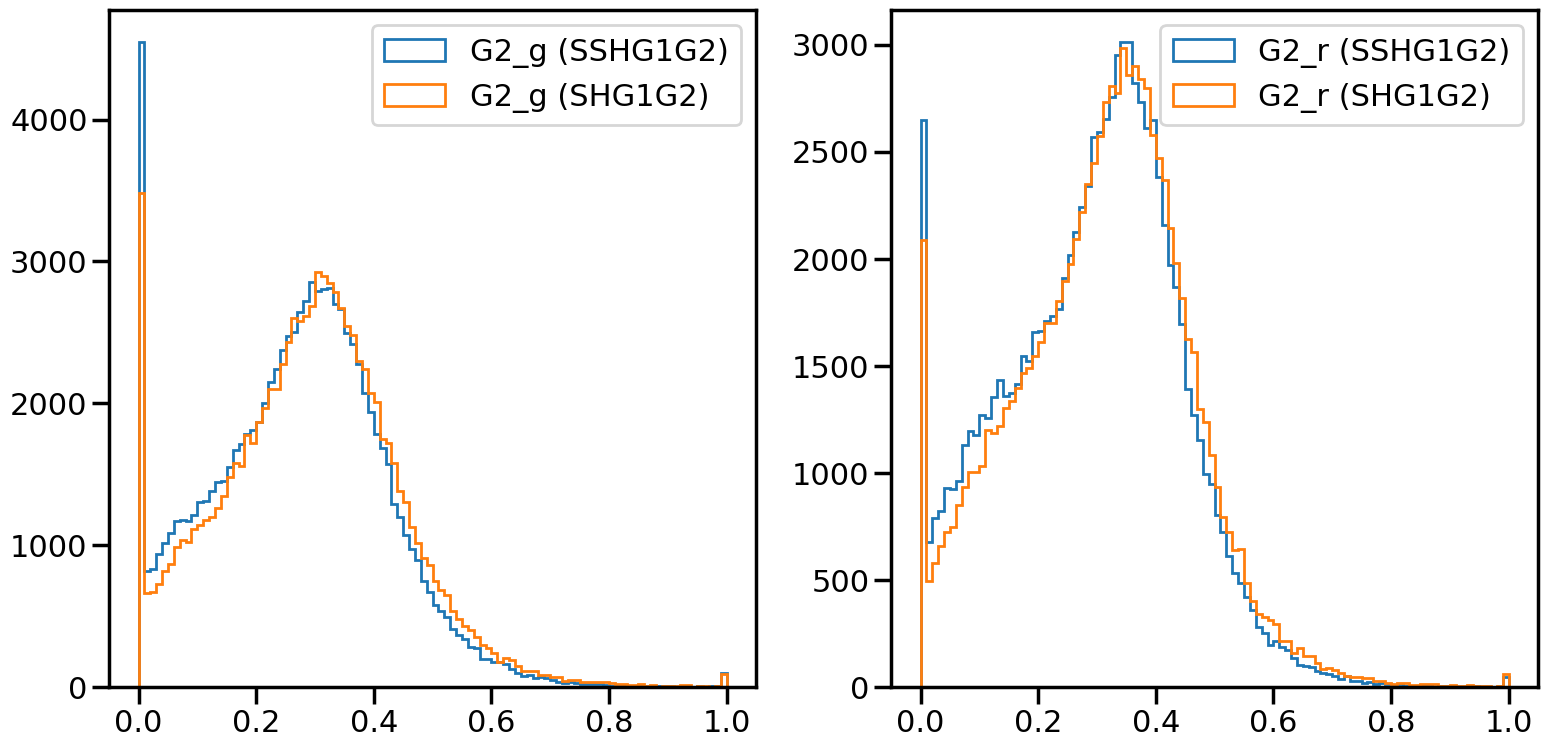

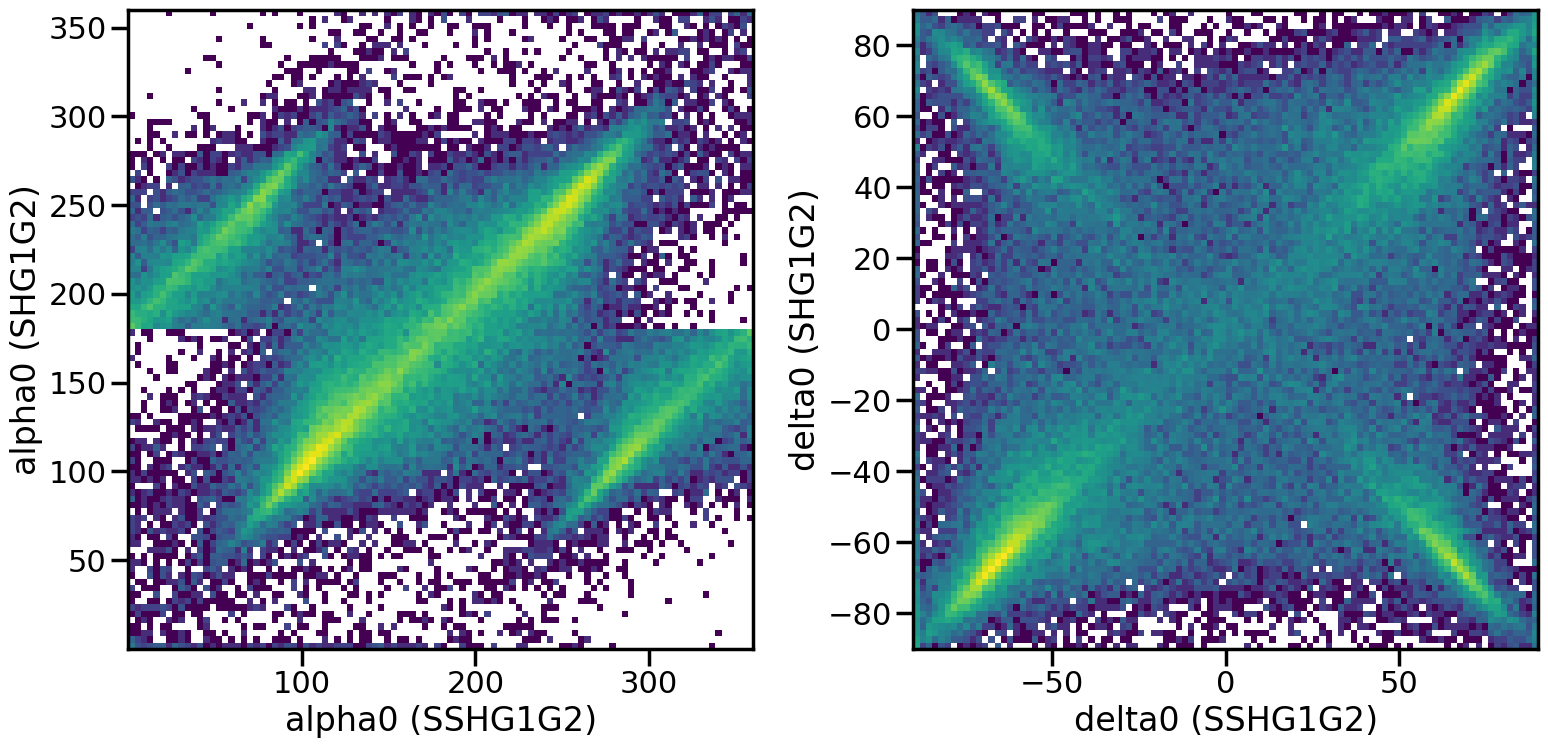

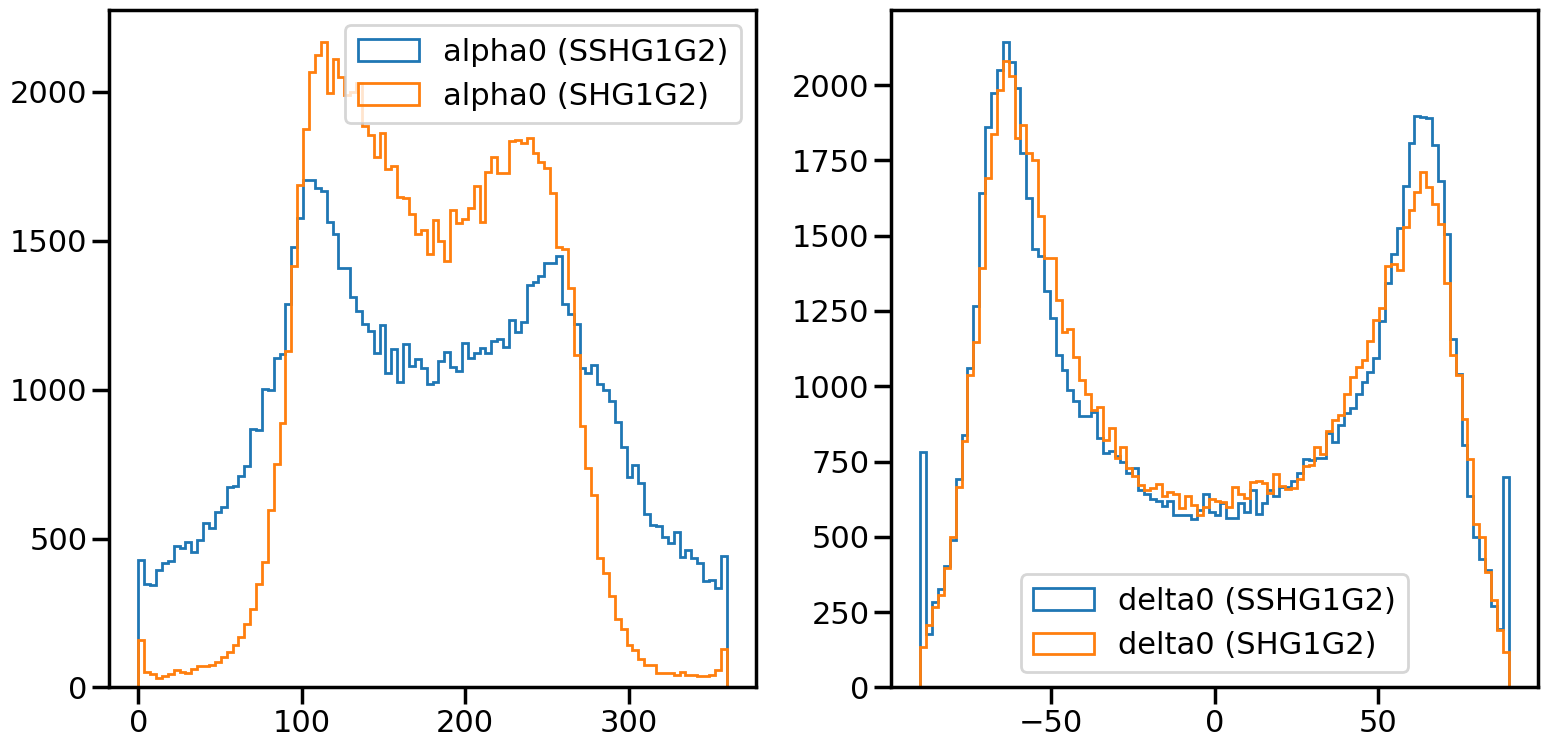

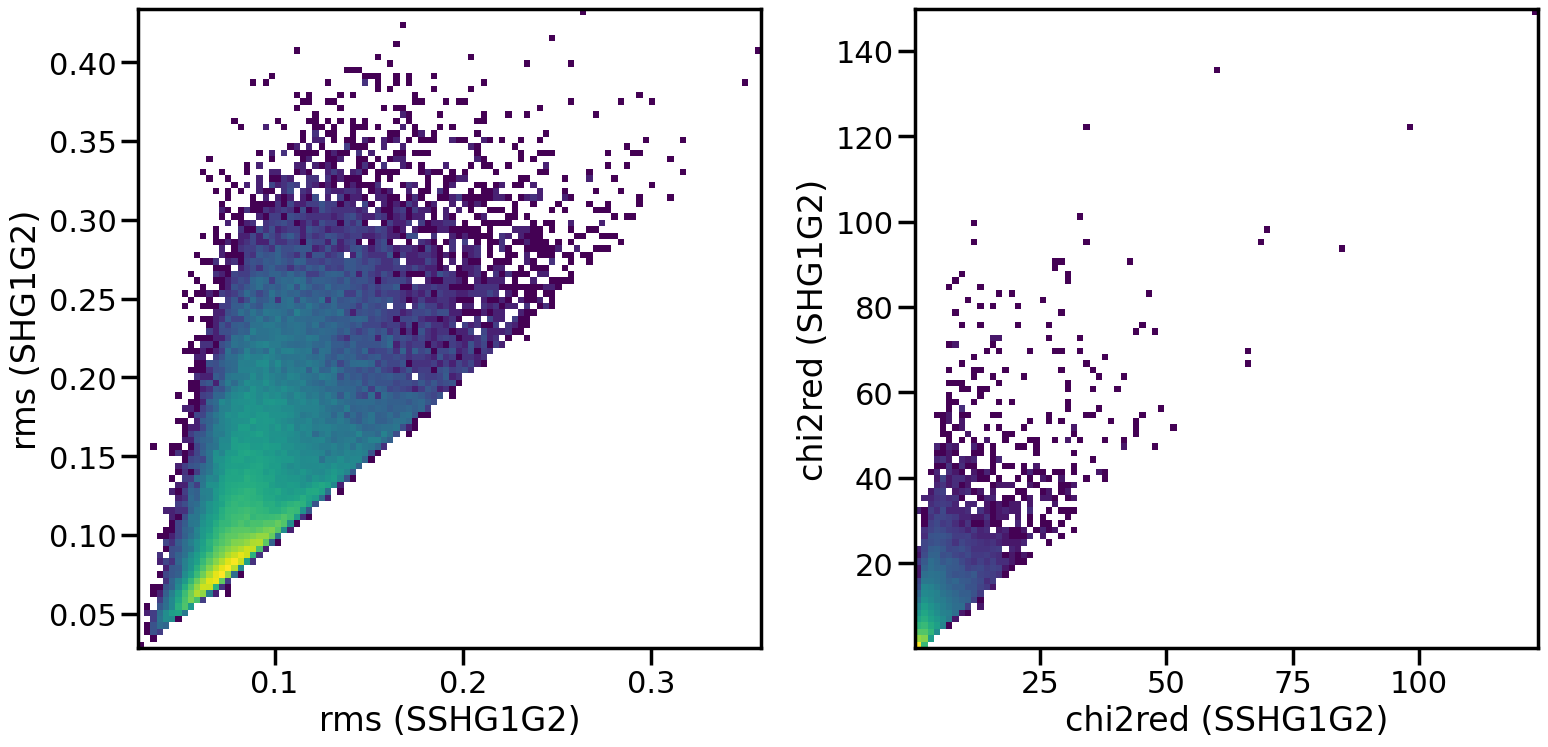

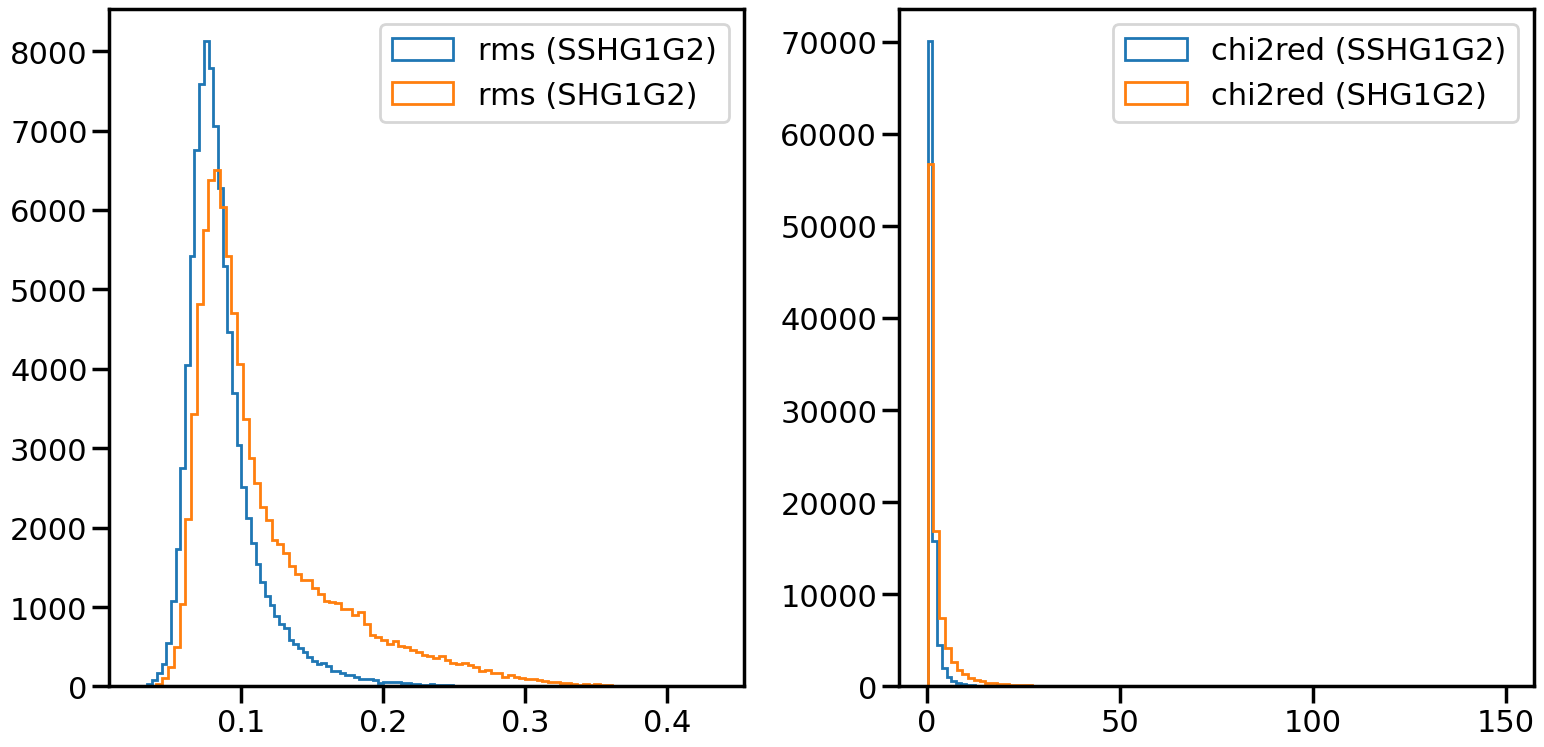

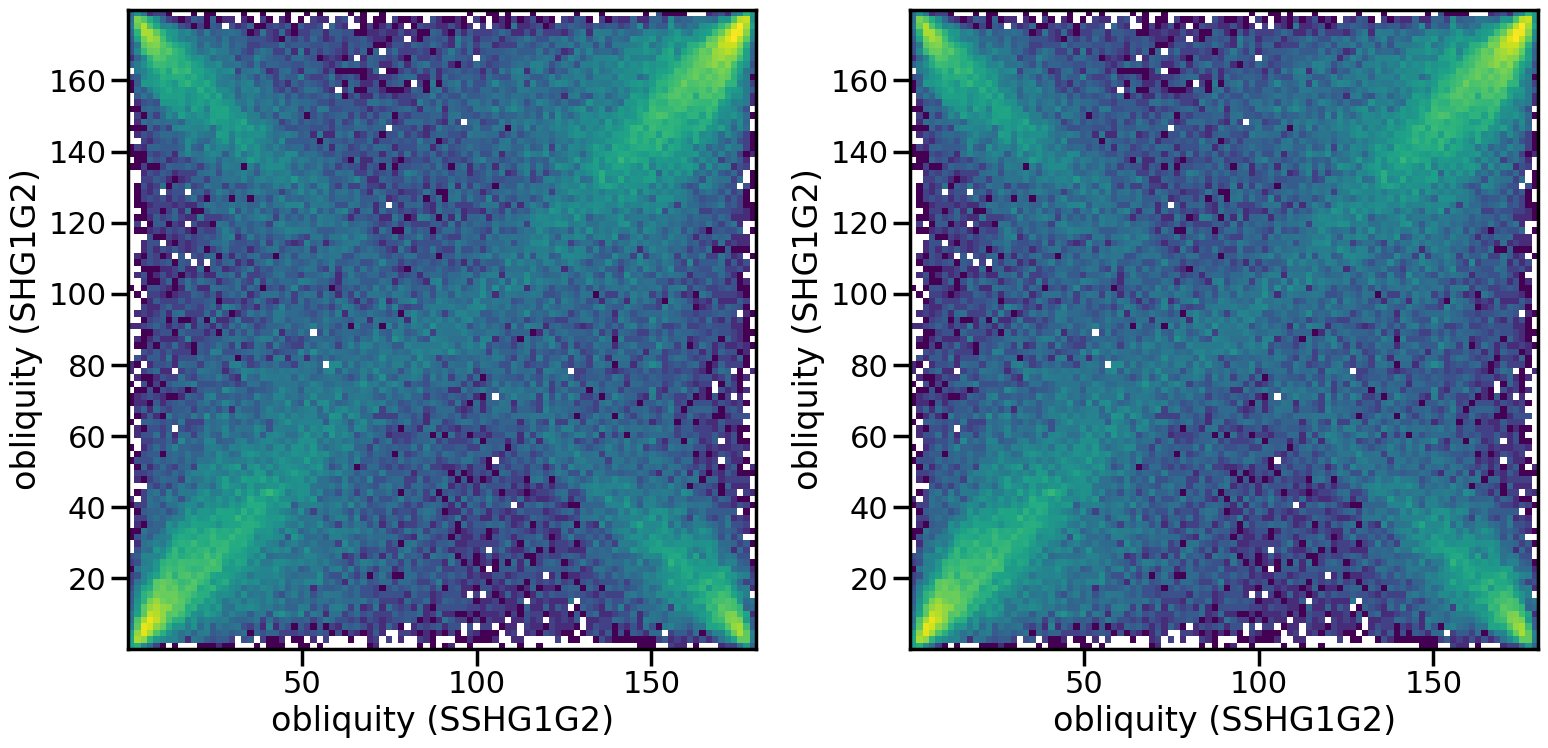

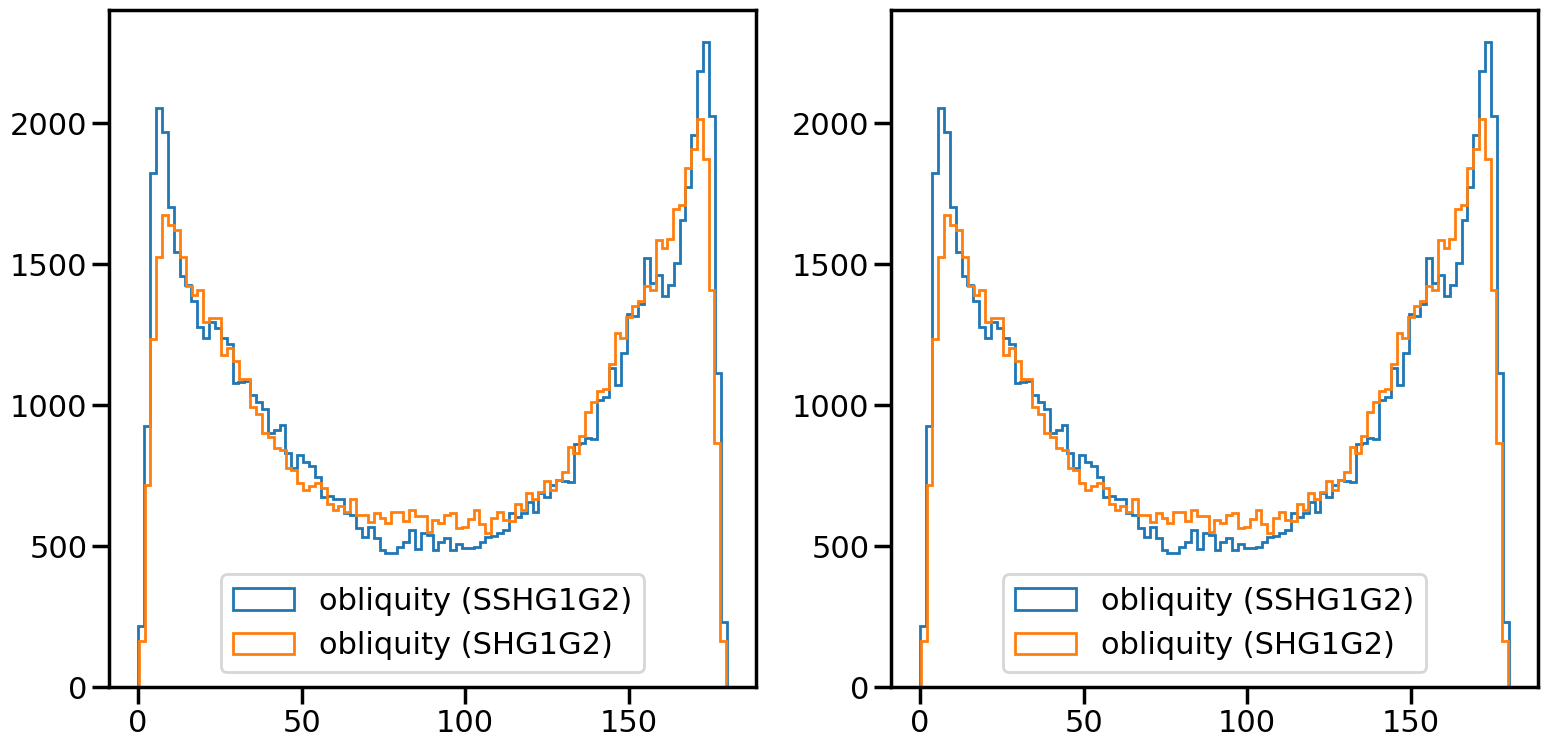

In [13]:
all_fields = [
    ["H_g", "H_r"],
    ["G1_g", "G1_r"],
    ["G2_g", "G2_r"],
    ["alpha0", "delta0"],
    ["rms", "chi2red"],
    ["obliquity", "obliquity"],
]

for fields in all_fields:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for index in range(2): 
        x = ssoft[mask]["{}_{}".format(flavors[0], fields[index])]
        y = ssoft[mask]["{}_{}".format(flavors[1], fields[index])]
        axes[index].hist2d(x, y, range=[[np.min(x), np.max(x)], [np.min(y), np.max(y)]], bins=100, norm="log") 
    
        axes[index].set_xlabel("{} ({})".format(fields[index], flavors[0]))
        axes[index].set_ylabel("{} ({})".format(fields[index], flavors[1]))
    
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for index in range(2): 
        x = ssoft[mask]["{}_{}".format(flavors[0], fields[index])]
        y = ssoft[mask]["{}_{}".format(flavors[1], fields[index])]
        axes[index].hist(x, bins=100, label="{} ({})".format(fields[index], flavors[0]), histtype="step")
        axes[index].hist(y, bins=100, label="{} ({})".format(fields[index], flavors[1]), histtype="step")

        axes[index].legend()
    plt.tight_layout()
    plt.show()

Text(0, 0.5, '(SSHG1G2_period - SHG1G2_period)/ SSHG1G2_period')

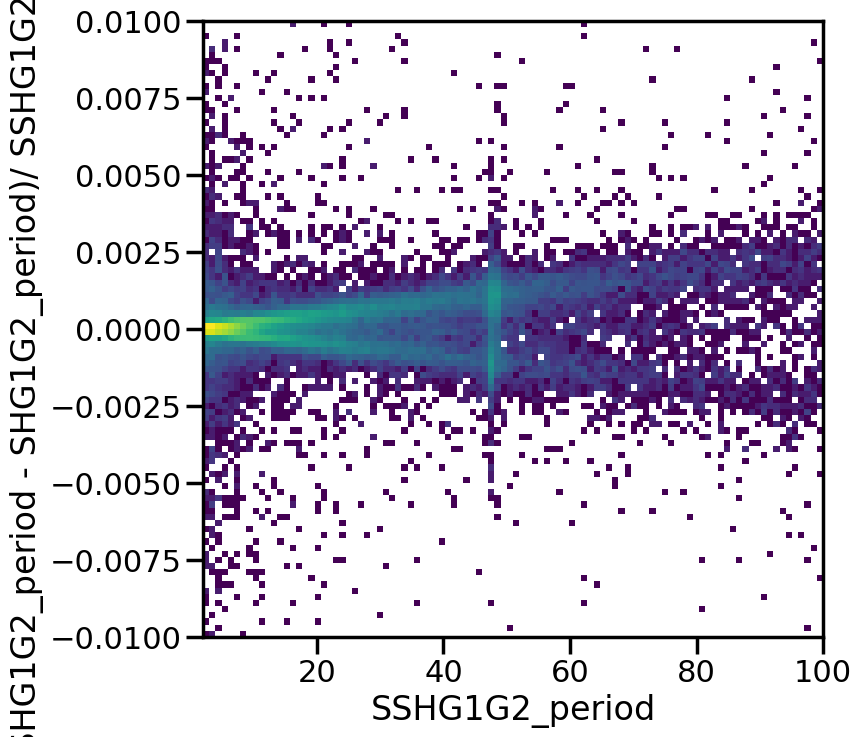

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

x = ssoft[mask]["SSHG1G2_period"] # periodogram + fit
y = ssoft[mask]["SHG1G2_period"] # pure periodogram

# plt.hist2d(x, y, range=[[0, 1000], [0, 1000]], bins=100, norm="log")
# plt.xlabel("SSHG1G2_period")
# plt.ylabel("SHG1G2_period")

plt.hist2d(x, (x-y)/x, range=[[2, 100], [-0.01, 0.01]], bins=100, norm="log")
plt.xlabel("SSHG1G2_period")
plt.ylabel("(SSHG1G2_period - SHG1G2_period)/ SSHG1G2_period")

In [22]:
ssoft[mask].groupby("SSHG1G2_combination").count()

,ssnamenr,HG_chi2red,HG_status,HG_fit,HG_rms,HG_rms_g,HG_rms_r,HG_median_error_phot,HG_median_error_phot_1,HG_median_error_phot_2,...,n_days_r,last_jd,name,number,SSHG1G2_obliquity_00,SSHG1G2_obliquity_01,SSHG1G2_obliquity_10,SSHG1G2_obliquity_11,version,SSHG1G2_flag
SSHG1G2_combination,,,,,,,,,,,,,,,,,,,,,
00,34681,34676,34681,34681,34676,34675,34676,34676,34675,34676,...,34681,34681,34679,34679,34679,34679,34679,34679,34681,34681
01,32396,32395,32396,32396,32395,32395,32395,32395,32395,32395,...,32396,32396,32396,32396,32396,32396,32396,32396,32396,32396
11,28507,28506,28507,28507,28506,28506,28506,28506,28506,28506,...,28507,28507,28504,28504,28504,28504,28504,28504,28507,28507


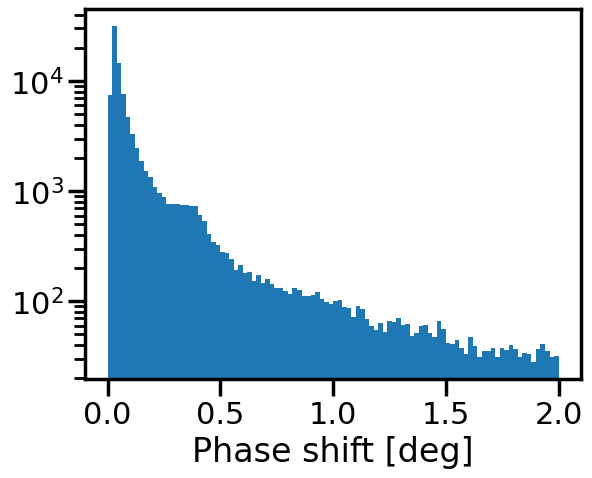

In [23]:
plt.hist(ssoft[mask]["SSHG1G2_phase_shift_deg"], bins=100, range=[0, 2]);
plt.xlabel("Phase shift [deg]")
plt.yscale("log")